# F1 Reliability & Grid Position Analysis

Business Questions Needed To Be Solved:
--Does starting position significantly affect a driver's ability to score points?
--How has F1 car reliability changed over the decades?
--Which constructors have the highest DNF rates?
--What are the most common reasons for race retirements?
--How much do DNFs impact overall race performance?

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

### load into sqlite

In [ ]:
files = {
    'race_results': 'data/race_results.csv',
    'races': 'data/races.csv',
    'drivers': 'data/drivers.csv',
    'constructors': 'data/constructors.csv',
    'circuits': 'data/circuits.csv',
    'status': 'data/status.csv'
}

conn = sqlite3.connect('f1.db')

for table, f in files.items():
    df = pd.read_csv(f)
    df.to_sql(table, conn, if_exists='replace', index=False)
    print(table, df.shape)

race_results (26759, 18)
races (1125, 13)
drivers (861, 8)
constructors (212, 4)
circuits (77, 7)
status (137, 3)


### join race results with race info

In [3]:
query = '''
select
    rr.season, rr.round, rr.driverId, rr.driverName, rr.constructorId, rr.constructorName,
    rr.grid, rr.position, rr.positionText, rr.points, rr.laps, rr.status,
    ra.raceName, ra.circuitId, ra.date
from race_results rr
join races ra on rr.season = ra.season and rr.round = ra.round
'''

df = pd.read_sql(query, conn)
df.shape

(26759, 15)

### cleaning

In [4]:
#check nulls
df.isnull().sum()

season             0
round              0
driverId           0
driverName         0
constructorId      0
constructorName    0
grid               0
position           0
positionText       0
points             0
laps               0
status             0
raceName           0
circuitId          0
date               0
dtype: int64

In [5]:
#positionText tells us if a driver actually finished or not
#R means retired/DNF, everything else is a real finishing position
df['positionText'].value_counts().head(10)

positionText
R    8897
F    1368
3    1135
4    1135
2    1133
5    1131
1    1128
6    1124
7    1104
8    1076
Name: count, dtype: int64

In [6]:
#convert date column properly
df['date'] = pd.to_datetime(df['date'])
df.dtypes

season                      int64
round                       int64
driverId                      str
driverName                    str
constructorId                 str
constructorName               str
grid                        int64
position                    int64
positionText                  str
points                    float64
laps                        int64
status                        str
raceName                      str
circuitId                     str
date               datetime64[us]
dtype: object

### feature engineering

In [7]:
#simple flag for did not finish
df['is_dnf'] = df['positionText'] == 'R'

#group into decades to see how reliability changed over f1 history
df['decade'] = (df['season'] // 10) * 10

df[['is_dnf','decade']].head()

,is_dnf,decade
0,False,1950
1,False,1950
2,False,1950
3,False,1950
4,False,1950


In [8]:
#bucket grid position so its easier to compare instead of 20 individual positions
df['grid_bucket'] = pd.cut(df['grid'], bins=[0,3,6,10,15,50], labels=['1-3','4-6','7-10','11-15','16+'])
df['grid_bucket'].value_counts()

grid_bucket
16+      8198
11-15    5617
7-10     4526
1-3      3391
4-6      3389
Name: count, dtype: int64

### analysis

In [9]:
#overall dnf rate across all of f1 history
print("overall dnf rate:", df['is_dnf'].mean())

overall dnf rate: 0.3324862663029261


In [10]:
#dnf rate by decade, this is the big one
decade_dnf = df.groupby('decade')['is_dnf'].mean()
decade_dnf

decade
1950    0.449925
1960    0.381448
1970    0.382716
1980    0.433489
1990    0.413882
2000    0.285753
2010    0.168722
2020    0.118747
Name: is_dnf, dtype: float64

In [11]:
#does grid position actually predict points scored
grid_points = df.groupby('grid_bucket', observed=True)['points'].mean()
grid_points

grid_bucket
1-3      7.179422
4-6      3.987456
7-10     1.947304
11-15    0.803632
16+      0.237697
Name: points, dtype: float64

In [12]:
#constructor reliability, only last 20 years so its relevant to current era
#only constructors with at least 50 race entries so one bad season doesnt skew it
recent = df[df['season'] >= 2005]

constructor_dnf = recent.groupby('constructorName').agg(
    total=('is_dnf','count'),
    dnf_rate=('is_dnf','mean')
)
constructor_dnf = constructor_dnf[constructor_dnf['total'] >= 50].sort_values('dnf_rate', ascending=False)

print("worst reliability:")
print(constructor_dnf.head(10))
print()
print("best reliability:")
print(constructor_dnf.tail(10))

worst reliability:
                 total  dnf_rate
constructorName                 
Super Aguri         78  0.358974
Virgin              76  0.302632
HRT                116  0.275862
Lotus               76  0.263158
Toro Rosso         536  0.248134
Lotus F1           154  0.246753
Honda              106  0.216981
Toyota             178  0.207865
Sauber             440  0.204545
Renault            454  0.198238

best reliability:
                 total  dnf_rate
constructorName                 
Manor Marussia      78  0.141026
BMW Sauber         140  0.135714
Alpine F1 Team     180  0.133333
AlphaTauri         166  0.132530
Racing Point        76  0.131579
Alfa Romeo         208  0.125000
Marussia           109  0.119266
Ferrari            788  0.111675
Aston Martin       180  0.094444
Mercedes           610  0.091803


In [13]:
#what actually causes the dnfs, mechanical failure vs crash vs other
dnf_only = df[df['is_dnf']]
dnf_only['status'].value_counts().head(15)

status
Engine          1867
Accident         957
Collision        801
Gearbox          766
Spun off         753
Suspension       405
Transmission     309
Electrical       296
Brakes           234
Clutch           200
Turbo            142
Fuel system      137
Overheating      130
Hydraulics       130
Oil leak         123
Name: count, dtype: int64

### charts

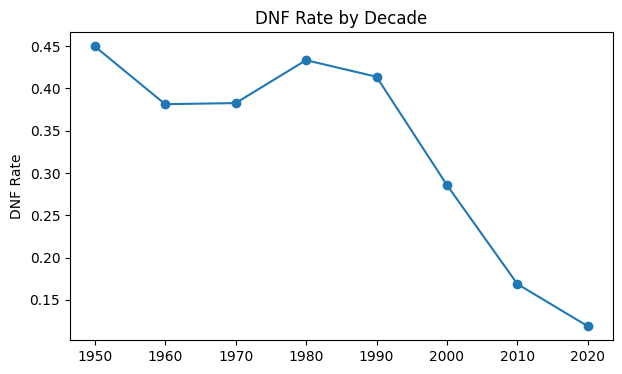

In [14]:
plt.figure(figsize=(7,4))
plt.plot(decade_dnf.index.astype(str), decade_dnf.values, marker='o')
plt.title('DNF Rate by Decade')
plt.ylabel('DNF Rate')
plt.show()+

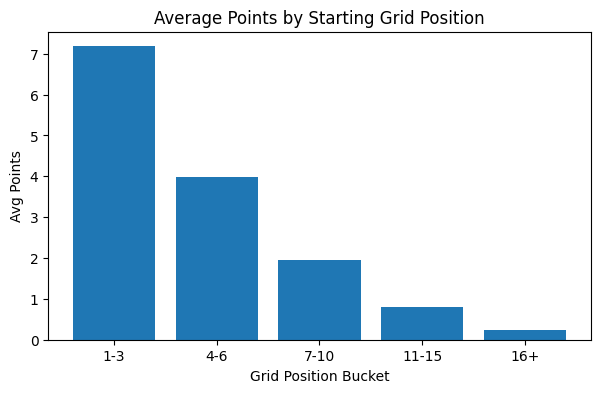

In [15]:
plt.figure(figsize=(7,4))
plt.bar(grid_points.index.astype(str), grid_points.values)
plt.title('Average Points by Starting Grid Position')
plt.ylabel('Avg Points')
plt.xlabel('Grid Position Bucket')
plt.show()

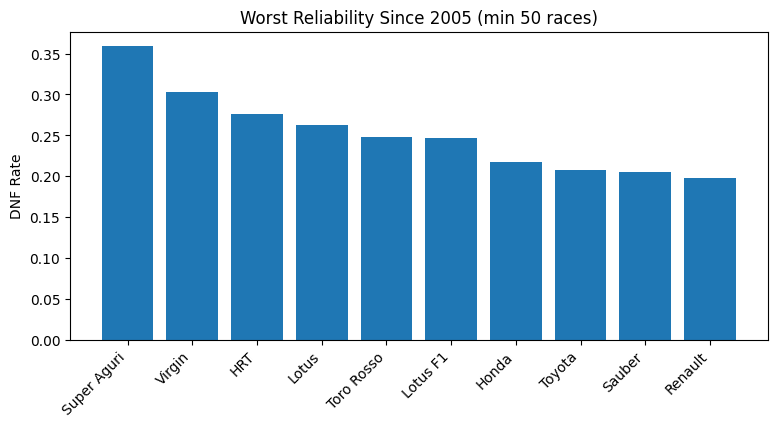

In [16]:
worst10 = constructor_dnf.head(10)
plt.figure(figsize=(9,4))
plt.bar(worst10.index, worst10['dnf_rate'])
plt.title('Worst Reliability Since 2005 (min 50 races)')
plt.ylabel('DNF Rate')
plt.xticks(rotation=45, ha='right')
plt.show()

### Insights

- Does starting position affect points? Yes, a lot. Drivers starting in the top 3 average 7.18 points per race, while drivers starting 16th or worse average just 0.24 points. Starting position is one of the strongest predictors of scoring.
- How has reliability changed over the decades? It's improved massively. DNF rate was 45% in the 1950s and stayed above 38% all the way through the 1990s. By the 2020s, it dropped to under 12%. Cars today are far more reliable than in F1's earlier decades.
- Which constructors have the highest DNF rates? Since 2005, Toro Rosso, Renault, and Sauber had the worst reliability among constructors with significant race volume. Mercedes (9.2%) and Ferrari (11.2%) were among the most reliable major teams in that period.
- What are the most common reasons for retirement? Mostly mechanical failures — engine, gearbox, and transmission issues — rather than crashes. This means reliability is largely an engineering problem, not a driver-error problem.
- How much do DNFs impact race performance? A DNF means zero points, regardless of how strong the car's pace was that race. Since most DNFs are mechanical rather than avoidable driver mistakes, a small reliability gap can directly cost a team significant points over a season.

### Reccomendations

- On starting position: Since grid position has such a big impact on points, teams should treat qualifying performance as a top priority, not secondary to race-day strategy. A strong car that qualifies poorly is already at a disadvantage before the race even starts.
- On reliability improving over time: The historical drop in DNF rate shows reliability investment pays off long-term. Teams should keep treating reliability engineering as an ongoing priority, not something to fix only after a bad season.
- On constructors with high DNF rates: Constructors with consistently high DNF rates (like the worst performers since 2005) should prioritize reliability upgrades over performance upgrades, since a fast but unreliable car scores fewer points than a slightly slower but consistent one.
- On common retirement causes: Since most retirements are mechanical rather than crashes, teams should focus engineering resources on the specific systems that fail most (engine, gearbox, transmission) rather than broadly blaming driver error.
- On the impact of DNFs: Because a single DNF wipes out all points for that race regardless of pace, teams should weigh reliability risk when pushing a car to its limits — sometimes finishing safely in a lower position is worth more over a season than risking a DNF for a shot at a higher one.
